In [1]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_parquet("./prediction_records_new.parquet")

print(df.shape)
print(df.head())
print(df["method"].value_counts())
print(df["parse_success"].value_counts())

(14822, 19)
                                                path file_type method  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   

           complex_name               prediction_id  rank target_chain_id  \
0  EGFR_amber-bat-stone  model_2_multimer_v3_pred_0     1               A   
1  EGFR_amber-bat-stone  model_5_multimer_v3_pred_0     2               B   
2  EGFR_amber-bat-stone  model_4_multimer_v3_pred_0     3               B   
3  EGFR_amber-bat-stone  model_3_multimer_v3_pred_0     4               B   
4  EGFR_amber-bat-stone  model_1_multimer_v3_pred_0     5               B   

  binder_chain_id  target_length  binder_length  \
0               B            621   

In [8]:
df[df["method"] == "OF3"][["binder_sequence","path", "method", "json_path", "pkl_path", "npz_path", "prediction_id", "rank", "score", "score_name", "file_type"]].head(10)

,binder_sequence,path,method,json_path,pkl_path,npz_path,prediction_id,rank,score,score_name,file_type
8812,SEIDEKLKQFLAQLEAEKGPGSEPATSGSETPGTSESATPESGPGP...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bat_stone_seed_42_sample_1_model,1,0.519886,sample_ranking_score,.cif
8813,SEIDEKLKQFLAQLEAEKGPGSEPATSGSETPGTSESATPESGPGP...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bat_stone_seed_42_sample_2_model,3,0.442260,sample_ranking_score,.cif
8814,SEIDEKLKQFLAQLEAEKGPGSEPATSGSETPGTSESATPESGPGP...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bat_stone_seed_42_sample_3_model,2,0.464928,sample_ranking_score,.cif
8815,SEIDEKLKQFLAQLEAEKGPGSEPATSGSETPGTSESATPESGPGP...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bat_stone_seed_42_sample_4_model,5,0.429807,sample_ranking_score,.cif
8816,SEIDEKLKQFLAQLEAEKGPGSEPATSGSETPGTSESATPESGPGP...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bat_stone_seed_42_sample_5_model,4,0.439621,sample_ranking_score,.cif
8817,SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLAA...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bear_ice_seed_42_sample_1_model,5,0.828710,sample_ranking_score,.cif
8818,SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLAA...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bear_ice_seed_42_sample_2_model,4,0.831431,sample_ranking_score,.cif
8819,SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLAA...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bear_ice_seed_42_sample_3_model,3,0.836541,sample_ranking_score,.cif
8820,SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLAA...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bear_ice_seed_42_sample_4_model,1,0.840775,sample_ranking_score,.cif
8821,SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLAA...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,OF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,NaN,NaN,amber_bear_ice_seed_42_sample_5_model,2,0.836723,sample_ranking_score,.cif


In [33]:
rank1_df = pd.read_parquet("rank1_structures.parquet")
print(rank1_df.groupby("binder_sequence")["method"].nunique().value_counts().sort_index())
print(rank1_df.head())

method
3      2
9    400
Name: count, dtype: int64
                                     binder_sequence      method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...  HelixFold3   

                                                path  rank file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   

  binder_chain_id target_chain_id     score       score_name  
0               B               A  0.903964 

In [31]:
df2 = pd.read_parquet("./pairwise_method_comparisons_rank1_only.parquet")

print(df2.shape)
print(df2.head())

(14406, 15)
                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         OF2   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .pdb        .cif   
1  /home/postyr/Assessing-AI

In [10]:
pair_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/pairwise_method_comparisons_rank1_with_binder_ca_rmsd.parquet")
print(pair_df.shape)
print(pair_df.head())

(14406, 21)
                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         OF2   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .pdb        .cif   
1  /home/postyr/Assessing-AI

In [11]:
print(pair_df["file_type_1"].value_counts(dropna=False))
print(pair_df["file_type_2"].value_counts(dropna=False))

file_type_1
.cif    10006
.pdb     4400
Name: count, dtype: int64
file_type_2
.cif    12406
.pdb     2000
Name: count, dtype: int64


In [12]:
print(pair_df["status"].value_counts(dropna=False))

status
ok    14406
Name: count, dtype: int64


In [14]:
print(pair_df["binder_ca_rmsd_align_binder"].describe())

count    14406.000000
mean         6.860813
std          6.682981
min          0.128339
25%          1.012620
50%          4.287116
75%         11.650795
max         62.745768
Name: binder_ca_rmsd_align_binder, dtype: float64


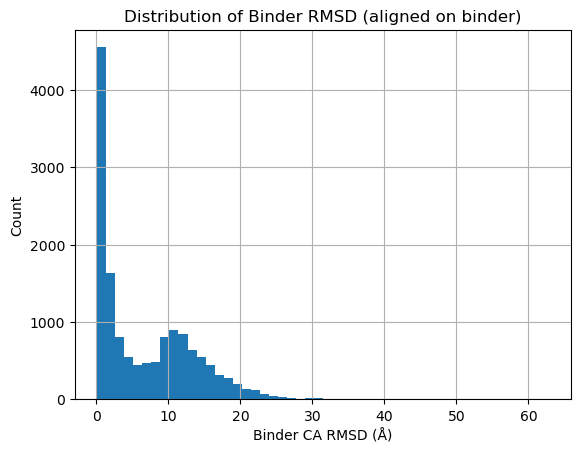

In [15]:
import matplotlib.pyplot as plt

pair_df["binder_ca_rmsd_align_binder"].hist(bins=50)
plt.xlabel("Binder CA RMSD (Å)")
plt.ylabel("Count")
plt.title("Distribution of Binder RMSD (aligned on binder)")
plt.show()

In [16]:
sample = pair_df.sample(5, random_state=0)

print(sample[[
    "method_1",
    "method_2",
    "binder_ca_rmsd_align_binder",
    "structure_path_1",
    "structure_path_2"
]])

         method_1  method_2  binder_ca_rmsd_align_binder  \
7587   HelixFold3       OF3                     6.431005   
3683          AF3       OF2                     0.639790   
9331          AF2       OF2                    18.385407   
10539      Chai-1  Protenix                     0.472179   
6461      Boltz-2       OF2                    12.616739   

                                        structure_path_1  \
7587   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3683   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
9331   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
10539  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
6461   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                        structure_path_2  
7587   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
3683   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
9331   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
10539  /home/postyr/Assessing-AI-Scoring-A

In [17]:
pair_df["pair"] = pair_df.apply(
    lambda r: " vs ".join(sorted([r["method_1"], r["method_2"]])),
    axis=1
)

print(
    pair_df.groupby("pair")["binder_ca_rmsd_align_binder"]
    .describe()
    .sort_values("mean")
)

                        count      mean       std       min       25%  \
pair                                                                    
AF2 vs AF3              400.0  3.490914  5.365483  0.174064  0.534147   
AF2 vs SeedFold         400.0  3.726090  5.556121  0.212529  0.701903   
Chai-1 vs SeedFold      400.0  3.780521  5.133621  0.207198  0.766500   
AF3 vs SeedFold         400.0  3.840152  6.070959  0.180123  0.562780   
Boltz-2 vs SeedFold     400.0  3.850580  5.376121  0.213313  0.882161   
AF3 vs Boltz-2          402.0  4.121353  6.080115  0.201587  0.849300   
AF2 vs Chai-1           400.0  4.222827  5.655266  0.237918  0.887998   
AF3 vs Chai-1           400.0  4.236485  5.892812  0.208377  0.787147   
Boltz-2 vs Chai-1       400.0  4.263014  5.605704  0.254115  0.967486   
AF2 vs Boltz-2          400.0  4.295369  6.210652  0.185774  0.917815   
AF3 vs HelixFold3       400.0  5.471941  6.117751  0.181689  0.824660   
AF2 vs HelixFold3       400.0  5.609803  6.190984  

In [18]:
print((pair_df["binder_ca_rmsd_align_binder"] == 0).sum())

0


In [19]:
print(pair_df.sort_values(
    "binder_ca_rmsd_align_binder", ascending=False
).head(10)[[
    "method_1", "method_2", "binder_ca_rmsd_align_binder"
]])

        method_1  method_2  binder_ca_rmsd_align_binder
6859     Boltz-2  Protenix                    62.745768
6858     Boltz-2       OF3                    62.324338
6857     Boltz-2       OF2                    59.056293
6841         AF2   Boltz-2                    56.887808
6855     Boltz-2    Chai-1                    53.407982
6867  HelixFold3       OF3                    49.059591
6848         AF3   Boltz-2                    47.798657
6860     Boltz-2  SeedFold                    47.653478
9721         OF3  SeedFold                    45.950256
6866  HelixFold3       OF2                    44.283044


In [20]:
target_rmsd_df = pd.read_parquet("./pairwise_method_comparisons_rank1_with_binder_ca_rmsd_and_target_shell_rmsd.parquet")
print(target_rmsd_df.shape)
print(target_rmsd_df.head())

(14406, 28)
                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         OF2   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .pdb        .cif   
1  /home/postyr/Assessing-AI

In [21]:
print(target_rmsd_df["file_type_1"].value_counts(dropna=False))
print(target_rmsd_df["file_type_2"].value_counts(dropna=False))

file_type_1
.cif    10006
.pdb     4400
Name: count, dtype: int64
file_type_2
.cif    12406
.pdb     2000
Name: count, dtype: int64


In [23]:
print(target_rmsd_df["status"].value_counts(dropna=False))

status
ok    14406
Name: count, dtype: int64


In [22]:
print(target_rmsd_df["binder_ca_rmsd_align_target_shell"].describe())

count    14406.000000
mean        23.303029
std         20.396502
min          0.206515
25%          5.510120
50%         18.805887
75%         35.435803
max        130.871069
Name: binder_ca_rmsd_align_target_shell, dtype: float64


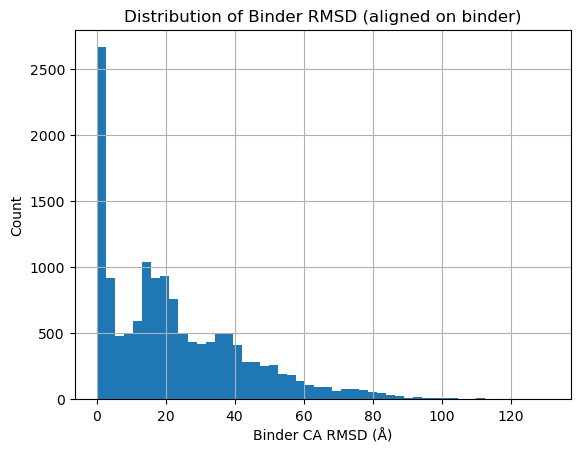

In [24]:
import matplotlib.pyplot as plt

target_rmsd_df["binder_ca_rmsd_align_target_shell"].hist(bins=50)
plt.xlabel("Binder CA RMSD (Å)")
plt.ylabel("Count")
plt.title("Distribution of Binder RMSD (aligned on binder)")
plt.show()

In [25]:
sample = target_rmsd_df.sample(5, random_state=0)

print(sample[[
    "method_1",
    "method_2",
    "binder_ca_rmsd_align_target_shell",
    "structure_path_1",
    "structure_path_2"
]])

         method_1  method_2  binder_ca_rmsd_align_target_shell  \
7587   HelixFold3       OF3                         102.935237   
3683          AF3       OF2                          18.966316   
9331          AF2       OF2                          21.352344   
10539      Chai-1  Protenix                          19.606128   
6461      Boltz-2       OF2                          16.091699   

                                        structure_path_1  \
7587   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3683   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
9331   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
10539  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
6461   /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                        structure_path_2  
7587   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
3683   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
9331   /home/postyr/Assessing-AI-Scoring-Accuracy-for...  
10539 

In [26]:
target_rmsd_df["pair"] = target_rmsd_df.apply(
    lambda r: " vs ".join(sorted([r["method_1"], r["method_2"]])),
    axis=1
)

print(
    target_rmsd_df.groupby("pair")["binder_ca_rmsd_align_target_shell"]
    .describe()
    .sort_values("mean")
)

                        count       mean        std       min        25%  \
pair                                                                       
AF2 vs OF2              400.0  16.318295  11.200579  0.206515   9.182844   
AF2 vs Chai-1           400.0  16.930522  18.370458  0.371105   2.074267   
AF2 vs SeedFold         400.0  17.138648  21.246883  0.416274   1.544847   
AF2 vs Boltz-2          400.0  18.141334  19.674074  0.445717   1.940320   
HelixFold3 vs OF2       400.0  18.408534  13.545049  0.452042  10.584003   
AF2 vs OF3              400.0  18.513354  15.548152  0.365474   6.190729   
HelixFold3 vs OF3       400.0  20.389121  17.742278  0.329559   7.158741   
Boltz-2 vs Chai-1       400.0  20.405261  21.192607  0.422656   3.070911   
HelixFold3 vs SeedFold  400.0  20.596037  20.938231  0.557543   3.543627   
AF3 vs SeedFold         400.0  20.756524  25.613348  0.376520   1.475337   
AF2 vs HelixFold3       400.0  21.017555  21.764412  0.347330   3.514814   
OF2 vs OF3  

In [34]:
contact_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_contact_summary_5A.parquet")
print(contact_df.head())

                                     binder_sequence      method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...  HelixFold3   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   

  binder_chain_id target_chain_id     score       score_name  contact_cutoff  \
0               B               A  0.903964         iptm+ptm             5.0   
1               A               B 

**Target contact residues = all target residues where ANY atom is within 5Å of ANY binder atom. How much of EGFR is being touched**

**Binder contact residues = 18 residues on the binder are involved in the interface. How much of the binder participates**

**Residue contact pairs = So this counts all interactions, not just unique residues. Interface density / complexity. Hihg is many cross connections, low is sparse, possibly weakr or more linear interaction**

In [35]:
target_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_target_contacts_long_5A.parquet")
print(target_df.head())

                                     binder_sequence method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   

  binder_chain_id target_chain_id     score score_name  contact_cutoff  \
0               B               A  0.903964   iptm+ptm             5.0   
1               B               A  0.903964   iptm+ptm             5.0   
2 